Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Iris.csv")

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.duplicated().sum()

0

In [5]:
df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [7]:
df = df.drop(columns=['Id'])

In [8]:
num_features = df.select_dtypes(include=['float64','int64']).columns
cat_features = df.select_dtypes(include=['object']).columns

print the numerical and categorical features

In [9]:

print("Numberical_Featurs:", list(num_features))
print("Categorical_Featurs:", list(cat_features))

Numberical_Featurs: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
Categorical_Featurs: ['Species']


In [10]:
df.sample(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
13,4.3,3.0,1.1,0.1,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
44,5.1,3.8,1.9,0.4,Iris-setosa
92,5.8,2.6,4.0,1.2,Iris-versicolor
122,7.7,2.8,6.7,2.0,Iris-virginica



1. List its features and their types

In [11]:
import pandas as pd

# Create table
feature_table = pd.DataFrame({
    "Feature": df.columns,
    "Type": ["Categorical" if df[col].dtype == 'object' else "Numerical" for col in df.columns]
})

print(feature_table)

         Feature         Type
0  SepalLengthCm    Numerical
1   SepalWidthCm    Numerical
2  PetalLengthCm    Numerical
3   PetalWidthCm    Numerical
4        Species  Categorical


2. Histogram for each numeric features

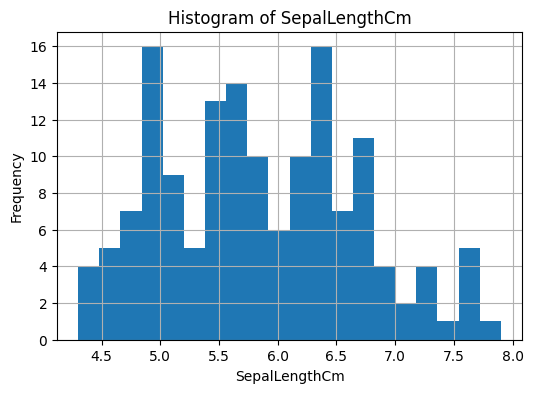

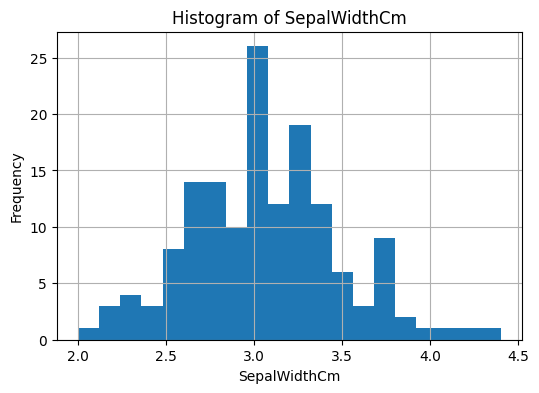

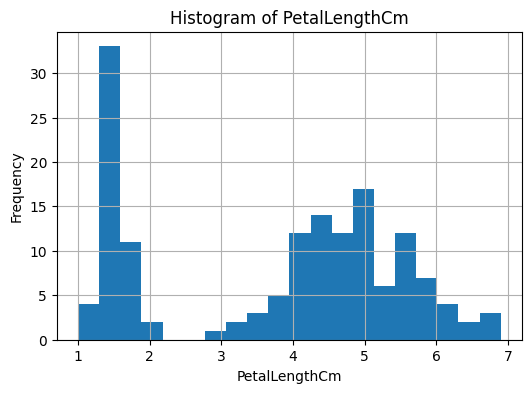

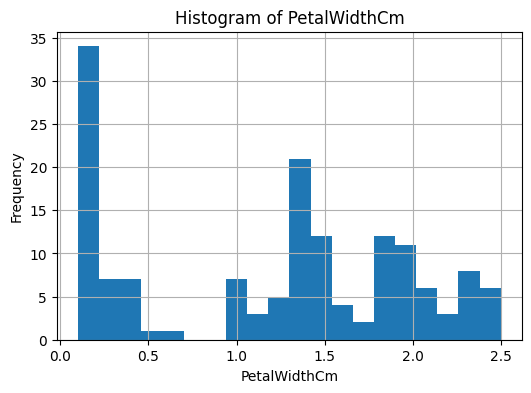

In [12]:
# Select numerical features
num_features = df.select_dtypes(include=['float64', 'int64']).columns

# Plot histograms
for col in num_features:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()

3.Box Plot for each numerical features

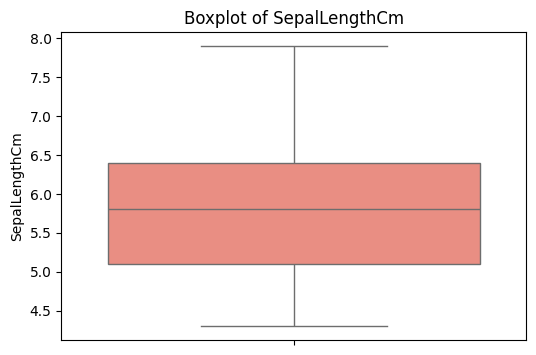

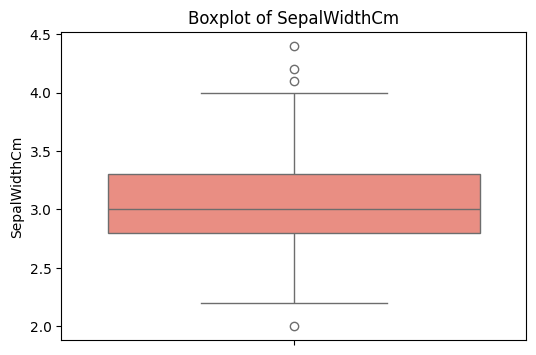

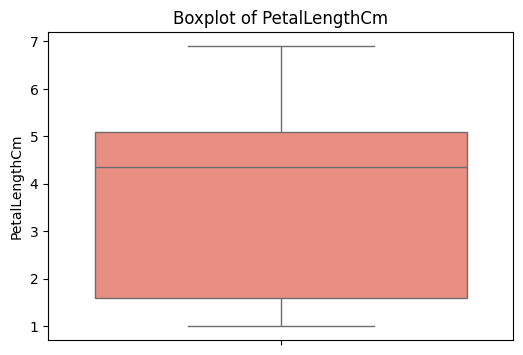

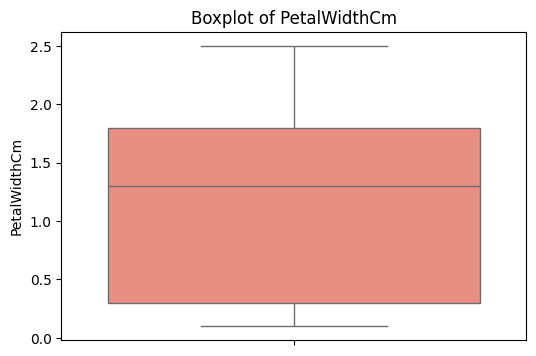

In [13]:
for col in num_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col], color='salmon')
    plt.title(f"Boxplot of {col}")
    plt.show()

6. IQR Outlier Detection

In [14]:
print("Outliers using IQR:")

for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")

Outliers using IQR:
SepalLengthCm: 0 outliers
SepalWidthCm: 4 outliers
PetalLengthCm: 0 outliers
PetalWidthCm: 0 outliers
